# analysis - cooccurrence by library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import igraph as ig
import networkx as nx
import matplotlib.pyplot as plt
import random
from daforfer import DaforferDB
from scipy import stats
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()
# db.tov()

┌──────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│         name         │                                                                                  description                                                                                   │
│       varchar        │                                                                                    varchar                                                                                     │
├──────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_sites              │ This table contains key information about each of the libraries, such as their site, habitat and host                                                                  

In [2]:
cooccurrence_pairs = db.conn.sql('SELECT * FROM D_coocPairDetections').df()
cooccurrence_pairs

,library,pair
0,PV003bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
1,PV004bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
2,PV005bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
3,PV007bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
4,PV012bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
...,...,...
340,PV544,Beet western yellows virus-Rhodococcoides fasc...
341,PV544,Beet western yellows virus-Sphingomonas sp. Le...
342,PV544,Beet chlorosis virus-Rhodococcoides fascians
343,PV544,Rhodococcoides fascians-Rubus chlorotic mottle...


In [3]:
cooccurrence_pairs_counts_by_library = cooccurrence_pairs.value_counts(['library']).reset_index()
cooccurrence_pairs_counts_by_library

,library,count
0,PV215,38
1,PV212,33
2,PV217,19
3,PV218,17
4,PV224,16
...,...,...
70,PV132,1
71,PV157,1
72,PV169,1
73,PV004bgi,1


In [4]:
all_libraries = db.conn.sql("SELECT * FROM D_sites").df()[['library', 'site', 'habitat', 'host_taxon']]

cooccurrence_pairs_counts_by_library = pd.merge(all_libraries, cooccurrence_pairs_counts_by_library, on='library', how='left').fillna(0).sort_values(by='count', ascending=False)
cooccurrence_pairs_counts_by_library['pos'] = np.arange(len(cooccurrence_pairs_counts_by_library))
cooccurrence_pairs_counts_by_library

,library,site,habitat,host_taxon,count,pos
194,PV215,L3,Edge,Conyza bonariensis,38.0,0
191,PV212,L3,Edge,Amaranthus sp,33.0,1
196,PV217,L3,Edge,Datura stramonium,19.0,2
197,PV218,L3,Edge,Daucus sp,17.0,3
202,PV224,L3,Edge,Vicia sp,16.0,4
...,...,...,...,...,...,...
151,PV166,L2,Edge,Carduus bourgeanus,0.0,330
152,PV167,L2,Edge,Chenopodium album,0.0,331
153,PV168,L2,Edge,Conyza canadensis,0.0,332
155,PV170,L2,Edge,Lactuca serriola,0.0,333


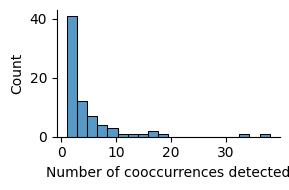

In [5]:
g = sns.displot(cooccurrence_pairs_counts_by_library.query('count > 0'), x='count', bins=20, height=2.0, aspect=1.5)
g.set_xlabels("Number of cooccurrences detected")
g.savefig("figures/displot.cooccurrences_by_library.svg")

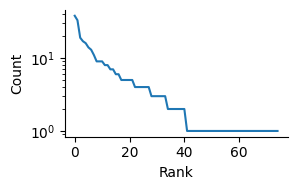

In [6]:
g = sns.relplot(cooccurrence_pairs_counts_by_library.query('count > 0'), x='pos', y='count', height=2.0, aspect=1.5, kind='line')
g.set_xlabels("Rank")
g.set_ylabels("Count")
g.ax.set_yscale('log')
g.savefig("figures/rankplot.cooccurrences_by_library.svg")

In [7]:
cooccurrence_pairs_counts_by_library[['count']].describe().round(4)

,count
count,335.0000
mean,1.0299
std,3.6492
min,0.0000
25%,0.0000
50%,0.0000
75%,0.0000
max,38.0000


In [8]:
cooccurrence_pairs_counts_by_library.query('count > 0')[['count']].describe().round(4)

,count
count,75.0000
mean,4.6000
std,6.5924
min,1.0000
25%,1.0000
50%,2.0000
75%,5.0000
max,38.0000


In [9]:
cooccurrence_pairs_counts_by_library = cooccurrence_pairs_counts_by_library[['library', 'site', 'habitat', 'host_taxon', 'count']]
cooccurrence_pairs_counts_by_library['count'] = cooccurrence_pairs_counts_by_library['count'].astype(int)
cooccurrence_pairs_counts_by_library

/var/folders/xl/z7y434d524s8xpvqnb0gst580000gn/T/ipykernel_49617/4000376895.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cooccurrence_pairs_counts_by_library['count'] = cooccurrence_pairs_counts_by_library['count'].astype(int)


,library,site,habitat,host_taxon,count
194,PV215,L3,Edge,Conyza bonariensis,38
191,PV212,L3,Edge,Amaranthus sp,33
196,PV217,L3,Edge,Datura stramonium,19
197,PV218,L3,Edge,Daucus sp,17
202,PV224,L3,Edge,Vicia sp,16
...,...,...,...,...,...
151,PV166,L2,Edge,Carduus bourgeanus,0
152,PV167,L2,Edge,Chenopodium album,0
153,PV168,L2,Edge,Conyza canadensis,0
155,PV170,L2,Edge,Lactuca serriola,0


In [10]:
db.close()